In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'darkgrid')
df = pd.read_csv('../results/planner_results.csv')

In [28]:
df

,method,env_version,episode,solved,total_reward,steps,runtime_ms,avg_runtime_ms,nodes_expanded,deadlocks_pruned,dead_squares,pruning_rate
0,BFSAgent,Sokoban-v0,0,True,10.7,23,462.1112,462.1112,2074,1025,0,0.4942
1,BFSAgent,Sokoban-v0,1,True,5.5,75,2644.8796,1553.4954,14065,13359,0,0.9498
2,BFSAgent,Sokoban-v0,2,False,-20.0,200,2058.6209,1721.8706,1,3,7,3.0000
3,BFSAgent,Sokoban-v0,3,True,11.3,17,176.5659,1335.5444,85,118,0,1.3882
4,BFSAgent,Sokoban-v0,4,False,-20.0,200,1917.0671,1451.8489,1,1,4,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
85,GreedyAgent,Sokoban-v1,0,False,-12.0,120,1423.3539,1423.3539,1,1,9,1.0000
86,GreedyAgent,Sokoban-v1,1,True,7.4,66,1914.3701,1668.8620,32,32,0,1.0000
87,GreedyAgent,Sokoban-v1,2,False,-12.0,120,2895.4515,2077.7252,1,4,14,4.0000
88,GreedyAgent,Sokoban-v1,3,True,9.1,49,721.0791,1738.5637,165,72,0,0.4364


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   method            90 non-null     object 
 1   env_version       90 non-null     object 
 2   episode           90 non-null     int64  
 3   solved            90 non-null     bool   
 4   total_reward      90 non-null     float64
 5   steps             90 non-null     int64  
 6   runtime_ms        90 non-null     float64
 7   avg_runtime_ms    90 non-null     float64
 8   nodes_expanded    90 non-null     int64  
 9   deadlocks_pruned  90 non-null     int64  
 10  dead_squares      90 non-null     int64  
 11  pruning_rate      90 non-null     float64
dtypes: bool(1), float64(4), int64(5), object(2)
memory usage: 8.0+ KB


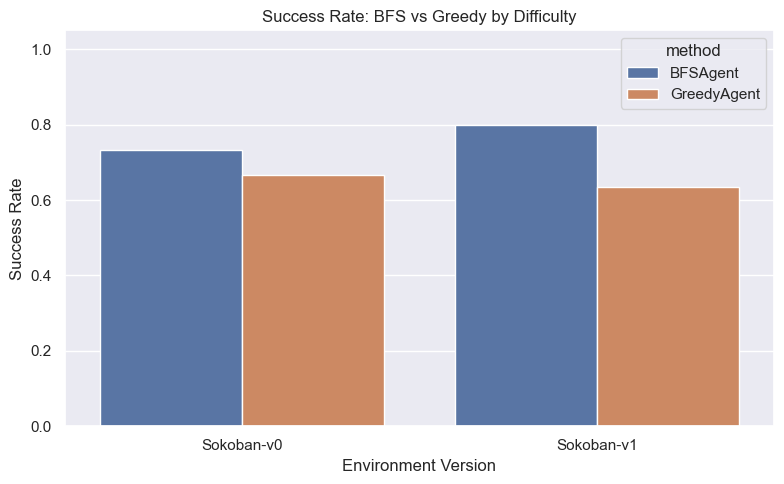

In [30]:
success = df.groupby(['method', 'env_version'])['solved'].mean().reset_index()
success.columns = ['method', 'env_version', 'success_rate']

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=success, x='env_version', y='success_rate', hue='method', ax=ax)
ax.set_title('Success Rate: BFS vs Greedy by Difficulty')

ax.set_ylabel('Success Rate')
ax.set_xlabel('Environment Version')

ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../results/fig_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()


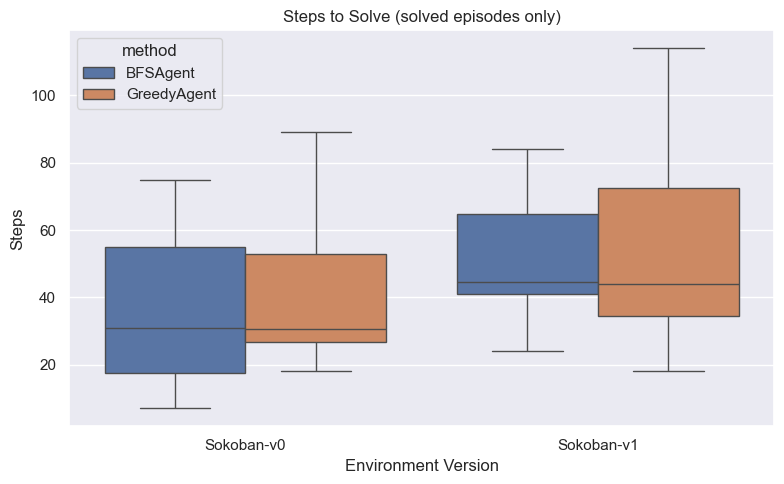

In [31]:
solved_df = df[df['solved'] == True]

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=solved_df, x='env_version', y='steps', hue='method', ax=ax)
ax.set_title('Steps to Solve (solved episodes only)')
ax.set_ylabel('Steps')
ax.set_xlabel('Environment Version')

plt.tight_layout()
plt.savefig('../results/fig_steps.png', dpi=150, bbox_inches='tight')
plt.show()


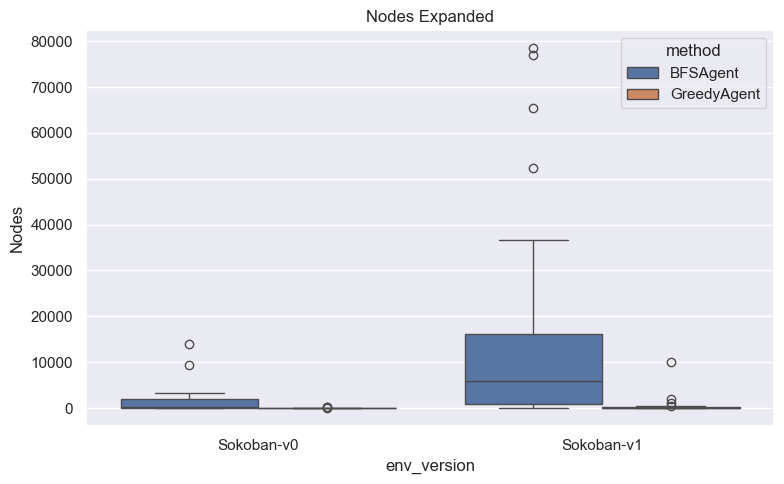

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='env_version', y='nodes_expanded', hue='method')
ax.set_title('Nodes Expanded')
ax.set_ylabel('Nodes')

plt.tight_layout()
plt.savefig('../results/node_exp_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


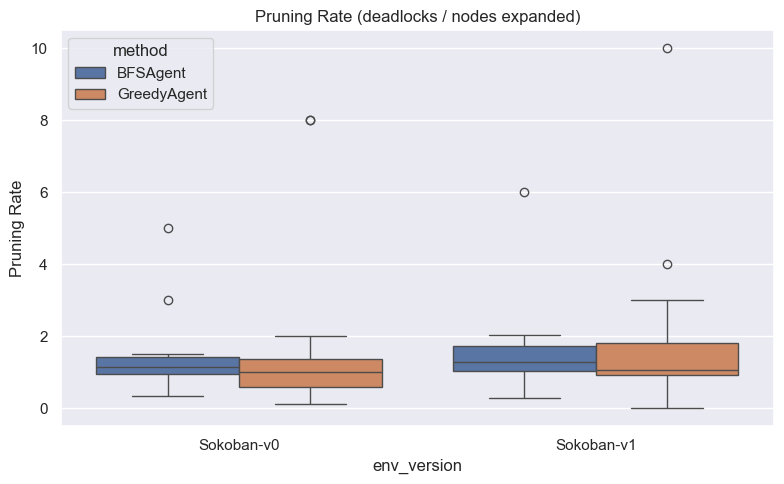

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='env_version', y='pruning_rate', hue='method')
ax.set_title('Pruning Rate (deadlocks / nodes expanded)')
ax.set_ylabel('Pruning Rate')

plt.tight_layout()
plt.savefig('../results/fig_search_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
summary = df.groupby(['method', 'env_version']).agg(
    success_rate=('solved', 'mean'),
    avg_reward=('total_reward', 'mean'),
    avg_steps=('steps', 'mean'),
    avg_runtime_ms=('runtime_ms', 'mean'),
    avg_nodes=('nodes_expanded', 'mean'),
    avg_pruning_rate=('pruning_rate', 'mean'),
    episodes=('episode', 'count')
).round(3).reset_index()

print(summary.to_string(index=False))
summary.to_csv('../results/planner_summary.csv', index=False)


     method env_version  success_rate  avg_reward  avg_steps  avg_runtime_ms  avg_nodes  avg_pruning_rate  episodes
   BFSAgent  Sokoban-v0         0.733       1.607     79.267        1093.228   2114.333             1.429        15
   BFSAgent  Sokoban-v1         0.800       4.707     64.933        6755.018  15244.867             1.527        30
GreedyAgent  Sokoban-v0         0.667      -0.740     94.067        1003.503     46.133             1.832        15
GreedyAgent  Sokoban-v1         0.633       1.040     78.933       18172.808    504.367             1.623        30
